
# Markowitz Portfolio (Yahoo Finance) — MSFT, NVDA, AAPL, GOOG

Este notebook construye un portafolio óptimo de **Markowitz** usando datos de **Yahoo Finance** vía `yfinance` para los tickers:
- `MSFT`, `NVDA`, `AAPL`, `GOOG`

Incluye:
- Descarga de **precios ajustados**
- Cálculo de **rendimientos**, **medias** y **covarianzas** anualizadas
- **Frontera eficiente**
- **Portafolio de mínima varianza**
- **Portafolio de máximo Sharpe**
- **Backtest** con rebalanceo **mensual**

> Requisitos: `pip install yfinance pandas numpy scipy matplotlib`


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime
from typing import List, Tuple, Optional



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\User\anaconda3\lib\site-packages\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\User\anaconda3\lib\site-packages\

AttributeError: _ARRAY_API not found

## 1) Descarga de datos

In [2]:

def fetch_price_data(
    tickers: List[str],
    start: str = "2019-01-01",
    end: Optional[str] = None,
    auto_adjust: bool = True,
    progress: bool = False,
) -> pd.DataFrame:
    """Descarga precios ajustados de Yahoo Finance para una lista de tickers.
    Devuelve un DataFrame 'Adj Close' con columnas = tickers.
    """
    if end is None:
        end = datetime.today().strftime("%Y-%m-%d")

    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=auto_adjust,
        progress=progress,
        group_by="column"
    )

    # Normalizar a un solo nivel de columnas (Adj Close o Close)
    if isinstance(data.columns, pd.MultiIndex):
        if "Adj Close" in data.columns.get_level_values(0):
            prices = data["Adj Close"].copy()
        elif "Close" in data.columns.get_level_values(0):
            prices = data["Close"].copy()
        else:
            lvl0 = data.columns.levels[0][0]
            prices = data[lvl0].copy()
    else:
        prices = data.copy()

    prices = prices.dropna(how="all", axis=1)
    prices = prices.sort_index().ffill().dropna(how="any")
    return prices

# Tickers solicitados
tickers = ["MSFT", "NVDA", "AAPL", "GOOG"]
prices = fetch_price_data(tickers, start="2019-01-01")
prices.tail()


Ticker,AAPL,GOOG,MSFT,NVDA
Date,,,,
2025-10-24,262.820007,260.510010,523.609985,186.259995
2025-10-27,268.809998,269.929993,531.520020,191.490005
2025-10-28,269.000000,268.429993,542.070007,201.029999
2025-10-29,269.700012,275.170013,541.549988,207.039993
2025-10-30,271.399994,281.899994,525.760010,202.889999


## 2) Rendimientos y estadísticas

In [3]:

# Rendimientos logarítmicos diarios
returns = np.log(prices / prices.shift(1)).dropna()

# Factor anual (252 días hábiles aprox.)
ANN = 252
mu = returns.mean() * ANN        # medias anualizadas
cov = returns.cov() * ANN        # covarianzas anualizadas

mu.to_frame('Annual Mean'), cov


(        Annual Mean
 Ticker             
 AAPL       0.290196
 GOOG       0.248260
 MSFT       0.251440
 NVDA       0.601097,
 Ticker      AAPL      GOOG      MSFT      NVDA
 Ticker                                        
 AAPL    0.098242  0.061203  0.063266  0.094941
 GOOG    0.061203  0.097902  0.063107  0.092403
 MSFT    0.063266  0.063107  0.081461  0.099116
 NVDA    0.094941  0.092403  0.099116  0.266751)

## 3) Funciones de optimización (Markowitz)

In [4]:

def portfolio_performance(weights: np.ndarray, mu: pd.Series, cov: pd.DataFrame, rf: float = 0.0):
    ret = float(np.dot(weights, mu.values))
    vol = float(np.sqrt(np.dot(weights, np.dot(cov.values, weights))))
    sharpe = (ret - rf) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

def min_variance(mu: pd.Series, cov: pd.DataFrame, allow_short: bool = False):
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(-1, 1)] * n if allow_short else [(0, 1)] * n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    res = minimize(lambda w: np.sqrt(np.dot(w, np.dot(cov.values, w))),
                   w0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 1000, "ftol": 1e-9})
    return res.x

def max_sharpe(mu: pd.Series, cov: pd.DataFrame, rf: float = 0.03, allow_short: bool = False):
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(-1, 1)] * n if allow_short else [(0, 1)] * n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    def neg_sharpe(w): 
        return -portfolio_performance(w, mu, cov, rf)[2]
    res = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 1000, "ftol": 1e-9})
    return res.x

def efficient_frontier(mu: pd.Series, cov: pd.DataFrame, n_points: int = 60, allow_short: bool = False):
    # Construye la frontera eficiente variando el retorno objetivo
    w_min = min_variance(mu, cov, allow_short=allow_short)
    r_min, v_min, _ = portfolio_performance(w_min, mu, cov)
    r_max = float(mu.max() * 1.1)  # exploración por arriba del mejor activo
    targets = np.linspace(r_min, r_max, n_points)

    out = []
    for tr in targets:
        bounds = [(-1, 1)] * len(mu) if allow_short else [(0, 1)] * len(mu)
        cons = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
            {"type": "eq", "fun": lambda w, rt=tr: float(np.dot(w, mu.values)) - rt}
        ]
        res = minimize(lambda w: np.sqrt(np.dot(w, np.dot(cov.values, w))),
                       np.ones(len(mu))/len(mu), method="SLSQP",
                       bounds=bounds, constraints=cons,
                       options={"maxiter": 1000, "ftol": 1e-9})
        if res.success:
            r, v, s = portfolio_performance(res.x, mu, cov)
            out.append({"ret": r, "vol": v, "sharpe": s, "weights": res.x})
    return pd.DataFrame(out)


## 4) Portafolios óptimos: Mín Var y Máx Sharpe

In [5]:

rf = 0.03          # tasa libre de riesgo anual (ajústala si deseas)
allow_short = False

w_minvar = min_variance(mu, cov, allow_short=allow_short)
w_maxsharpe = max_sharpe(mu, cov, rf=rf, allow_short=allow_short)

r_min, v_min, s_min = portfolio_performance(w_minvar, mu, cov, rf)
r_max, v_max, s_max = portfolio_performance(w_maxsharpe, mu, cov, rf)

w_minvar_s = pd.Series(w_minvar, index=prices.columns).sort_values(ascending=False)
w_maxsharpe_s = pd.Series(w_maxsharpe, index=prices.columns).sort_values(ascending=False)

print("=== Portafolio de Mínima Varianza ===")
print(w_minvar_s)
print(f"Rend anual: {r_min:.2%} | Vol anual: {v_min:.2%} | Sharpe: {s_min:.2f}\n")

print("=== Portafolio de Máximo Sharpe ===")
print(w_maxsharpe_s)
print(f"Rend anual: {r_max:.2%} | Vol anual: {v_max:.2%} | Sharpe: {s_max:.2f}")


=== Portafolio de Mínima Varianza ===
Ticker
MSFT    4.736628e-01
GOOG    2.654432e-01
AAPL    2.608940e-01
NVDA    7.155734e-17
dtype: float64
Rend anual: 26.07% | Vol anual: 26.80% | Sharpe: 0.86

=== Portafolio de Máximo Sharpe ===
Ticker
NVDA    6.740275e-01
AAPL    3.259725e-01
GOOG    1.595471e-17
MSFT    1.395910e-17
dtype: float64
Rend anual: 49.98% | Vol anual: 41.63% | Sharpe: 1.13


## 5) Frontera eficiente

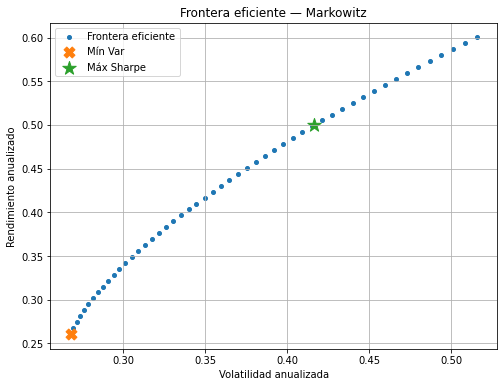

In [6]:

frontier = efficient_frontier(mu, cov, n_points=60, allow_short=allow_short)

# Gráfica en una sola figura, sin estilos ni colores específicos
plt.figure(figsize=(8,6))
plt.scatter(frontier["vol"], frontier["ret"], s=16, label="Frontera eficiente")
plt.scatter([v_min], [r_min], marker="X", s=120, label="Mín Var")
plt.scatter([v_max], [r_max], marker="*", s=200, label="Máx Sharpe")
plt.xlabel("Volatilidad anualizada")
plt.ylabel("Rendimiento anualizado")
plt.title("Frontera eficiente — Markowitz")
plt.legend()
plt.grid(True)
plt.show()


## 6) Backtest con rebalanceo mensual (portafolio Máx Sharpe)

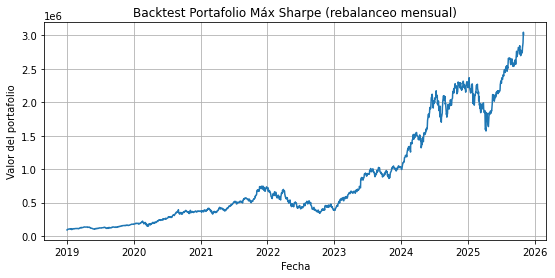

=== Métricas Backtest ===
annual_return: 51.09%
annual_vol: 41.53%
sharpe: 115.81%
initial_capital: 100,000.00
final_value: 3,011,599.87
total_return: 2911.60%


In [7]:

def backtest_rebalanced(
    prices: pd.DataFrame,
    target_weights: pd.Series,
    freq_rebalance: str = "M",
    initial_capital: float = 100_000.0,
) -> pd.DataFrame:
    # Rendimientos diarios log
    rets = np.log(prices / prices.shift(1)).dropna()
    rebal_dates = rets.resample(freq_rebalance).last().index

    capital = initial_capital
    weights = target_weights.reindex(prices.columns).fillna(0.0)
    portfolio_value = []
    dates = []

    current_weights = weights.copy()

    for date, row in rets.iterrows():
        if date in rebal_dates:
            current_weights = weights.copy()

        port_ret = float(np.dot(current_weights.values, row.reindex(weights.index).values))
        capital *= np.exp(port_ret)

        dates.append(date)
        portfolio_value.append(capital)

    bt = pd.DataFrame({"value": portfolio_value}, index=pd.to_datetime(dates))
    bt["ret"] = np.log(bt["value"] / bt["value"].shift(1)).fillna(0.0)

    ANN = 252
    ann_ret = bt["ret"].mean() * ANN
    ann_vol = bt["ret"].std() * np.sqrt(ANN)
    sharpe = (ann_ret - 0.03) / ann_vol if ann_vol > 0 else np.nan  # usa rf=3% por consistencia

    bt.attrs["metrics"] = {
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "initial_capital": initial_capital,
        "final_value": float(bt["value"].iloc[-1]),
        "total_return": float(bt["value"].iloc[-1] / initial_capital - 1.0),
    }
    return bt

target = w_maxsharpe_s
bt = backtest_rebalanced(prices, target, freq_rebalance="M", initial_capital=100_000.0)

# Curva de capital (una gráfica, sin colores específicos)
plt.figure(figsize=(9,4))
plt.plot(bt.index, bt["value"])
plt.title("Backtest Portafolio Máx Sharpe (rebalanceo mensual)")
plt.ylabel("Valor del portafolio")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()

print("=== Métricas Backtest ===")
for k, v in bt.attrs["metrics"].items():
    if isinstance(v, float):
        if "return" in k or "vol" in k or "sharpe" in k or "total" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v}")
